## Conversion de valores faltantes implicitos a explicitos

In [ ]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import numpy as np
import janitor

from src.pandas_accessors import MissingMethods
from src.data_loader import load_all_datasets

datasets = load_all_datasets()

<div style="background-color: rgba(255, 235, 59, 0.12); padding: 20px;">

### ⚠️ Advertencia

"Implícito se refiere a todo aquello que se entiende que está incluido pero sin ser expresado de forma directa o explícitamente."

Un valor faltante implícito indica que el valor faltante debería estar incluido en el conjunto de datos del análisis, sin que éste lo diga o lo especifique.
Por lo general, son valores que podemos encontrar al pivotar nuestros datos o contabilizar el número de apariciones de combinaciones de las variables de estudio.

</div>

### Generando nuestros datos

In [4]:
implicit_to_explicit_df = pd.DataFrame.from_dict(
    data = {
        "name": ["lynn", "lynn", "lynn", "zelda"],
        "time": ["morning", "afternoon", "night", "morning"],
        "value": [350, 310, np.nan, 320]
    }
)

implicit_to_explicit_df

,name,time,value
0,lynn,morning,350.0
1,lynn,afternoon,310.0
2,lynn,night,NaN
3,zelda,morning,320.0


### Estrategias para la identificacion de valores faltantes implicitos

#### Pivotar la tabla de datos

In [20]:
(
    implicit_to_explicit_df
    .pivot_table(
        index= "name",
        columns= "time",
        values= "value",
        dropna=False
    )
)

time,afternoon,morning,night
name,,,
lynn,310.0,350.0,NaN
zelda,NaN,320.0,NaN


#### Cuantificar ocurrencias de n-tuplas

In [29]:
(
    implicit_to_explicit_df
    .value_counts(
        subset=["name"]
    )
    .reset_index(name="Cantidad_Apariciones")
)

,name,Cantidad_Apariciones
0,lynn,3
1,zelda,1


### Exponer filas faltantes implicitas a explicitas

<div style="background-color: rgba(86, 145, 209, 0.16); padding: 16px; border-radius: 8px;">

#### 📘 Información

`janitor.complete()`

está modelada a partir de la función `complete()` del paquete `tidyr` y es un wrapper alrededor de `janitor.expand_grid()`, `pd.merge()`, y `pd.fillna()`. En cierto modo, es lo contrario de `pd.dropna()`, ya que expone implícitamente las filas que faltan.

Son posibles combinaciones de nombres de columnas o una lista/tupla de nombres de columnas, o incluso un diccionario de nombres de columna y nuevos valores.

</div>

#### Exponer n-tuplas de valores faltantes

Ejemplo, encontras los pares faltantes de name y time

In [28]:
(
    implicit_to_explicit_df
    .complete(
        "name",
        "time"
    )
)

,name,time,value
0,lynn,afternoon,310.0
1,lynn,morning,350.0
2,lynn,night,NaN
3,zelda,afternoon,NaN
4,zelda,morning,320.0
5,zelda,night,NaN


#### Limitar la exposicion de n-tuplas de valores faltantes

In [36]:
result = (
    implicit_to_explicit_df
    .complete(
        {
            "name": ["lynn", "zelda"],
            "time": ["morning", "afternoon"]
        }
    )
)

result["time"] = pd.Categorical(
    result["time"],
    categories=["morning", "afternoon", "night"],
    ordered=True
)

result = result.sort_values(["name", "time"])

result

,name,time,value
1,lynn,morning,350.0
0,lynn,afternoon,310.0
2,lynn,night,NaN
4,zelda,morning,320.0
3,zelda,afternoon,NaN


#### Rellenar valores faltantes

In [37]:
(
    implicit_to_explicit_df
    .complete(
        "name",
        "time",
        fill_value={"value": "N/A"}
    )
)

,name,time,value
0,lynn,afternoon,310.0
1,lynn,morning,350.0
2,lynn,night,N/A
3,zelda,afternoon,N/A
4,zelda,morning,320.0
5,zelda,night,N/A


#### Limitar el rellenado de valores faltantes implicitos

In [43]:
result = (
    implicit_to_explicit_df
    .complete(
        {
            "name": ["lynn", "zelda"],
            "time": ["morning", "afternoon", "night"]
        },
        fill_value = { "value": 0 },
        explicit= False
    )
)

result["time"] = pd.Categorical(
    result["time"],
    categories=["morning", "afternoon", "night"],
    ordered=True
)

result = result.sort_values(["name", "time"])

result

,name,time,value
1,lynn,morning,350.0
0,lynn,afternoon,310.0
2,lynn,night,NaN
4,zelda,morning,320.0
3,zelda,afternoon,0.0
5,zelda,night,0.0


### Tipos de valores faltantes

#### Explorando DataFrame

Asignamos, exploramos y convertimos los valores faltantes que se representavan con 0 a nan con np.nan

In [46]:
# Definiendo datadrame

diabetes_df = datasets['pima']

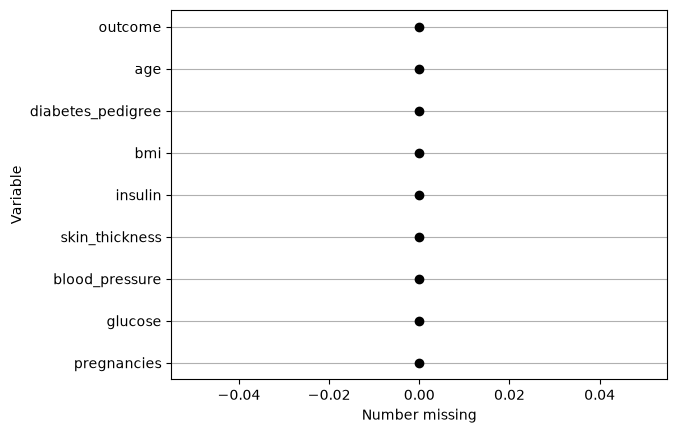

In [47]:
diabetes_df.missing.missing_variable_plot()

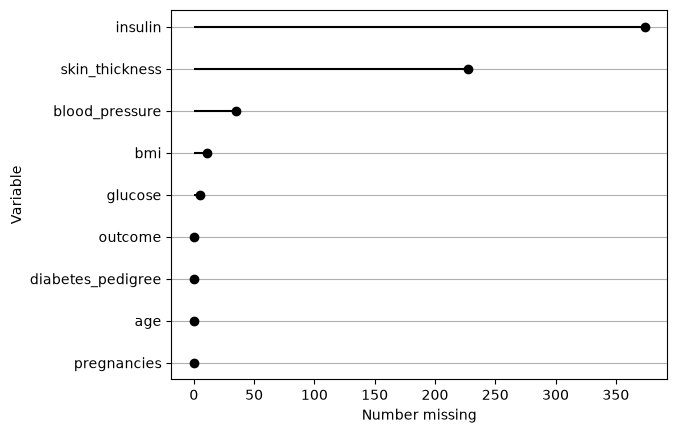

In [50]:
diabetes_df[diabetes_df.columns[1:6]] = diabetes_df[diabetes_df.columns[1:6]].replace(
    to_replace= 0,
    value= np.nan
)

diabetes_df.missing.missing_variable_plot()

#### Missing Completely At Random (MCAR)

Algo paso en su momento y no se pudo cuantificar esta cantidad, por eso se denomina que es al azar, este comportamiento lo podemos ver reflejado con bmi, glucose e incluso pregnancies

<Axes: >

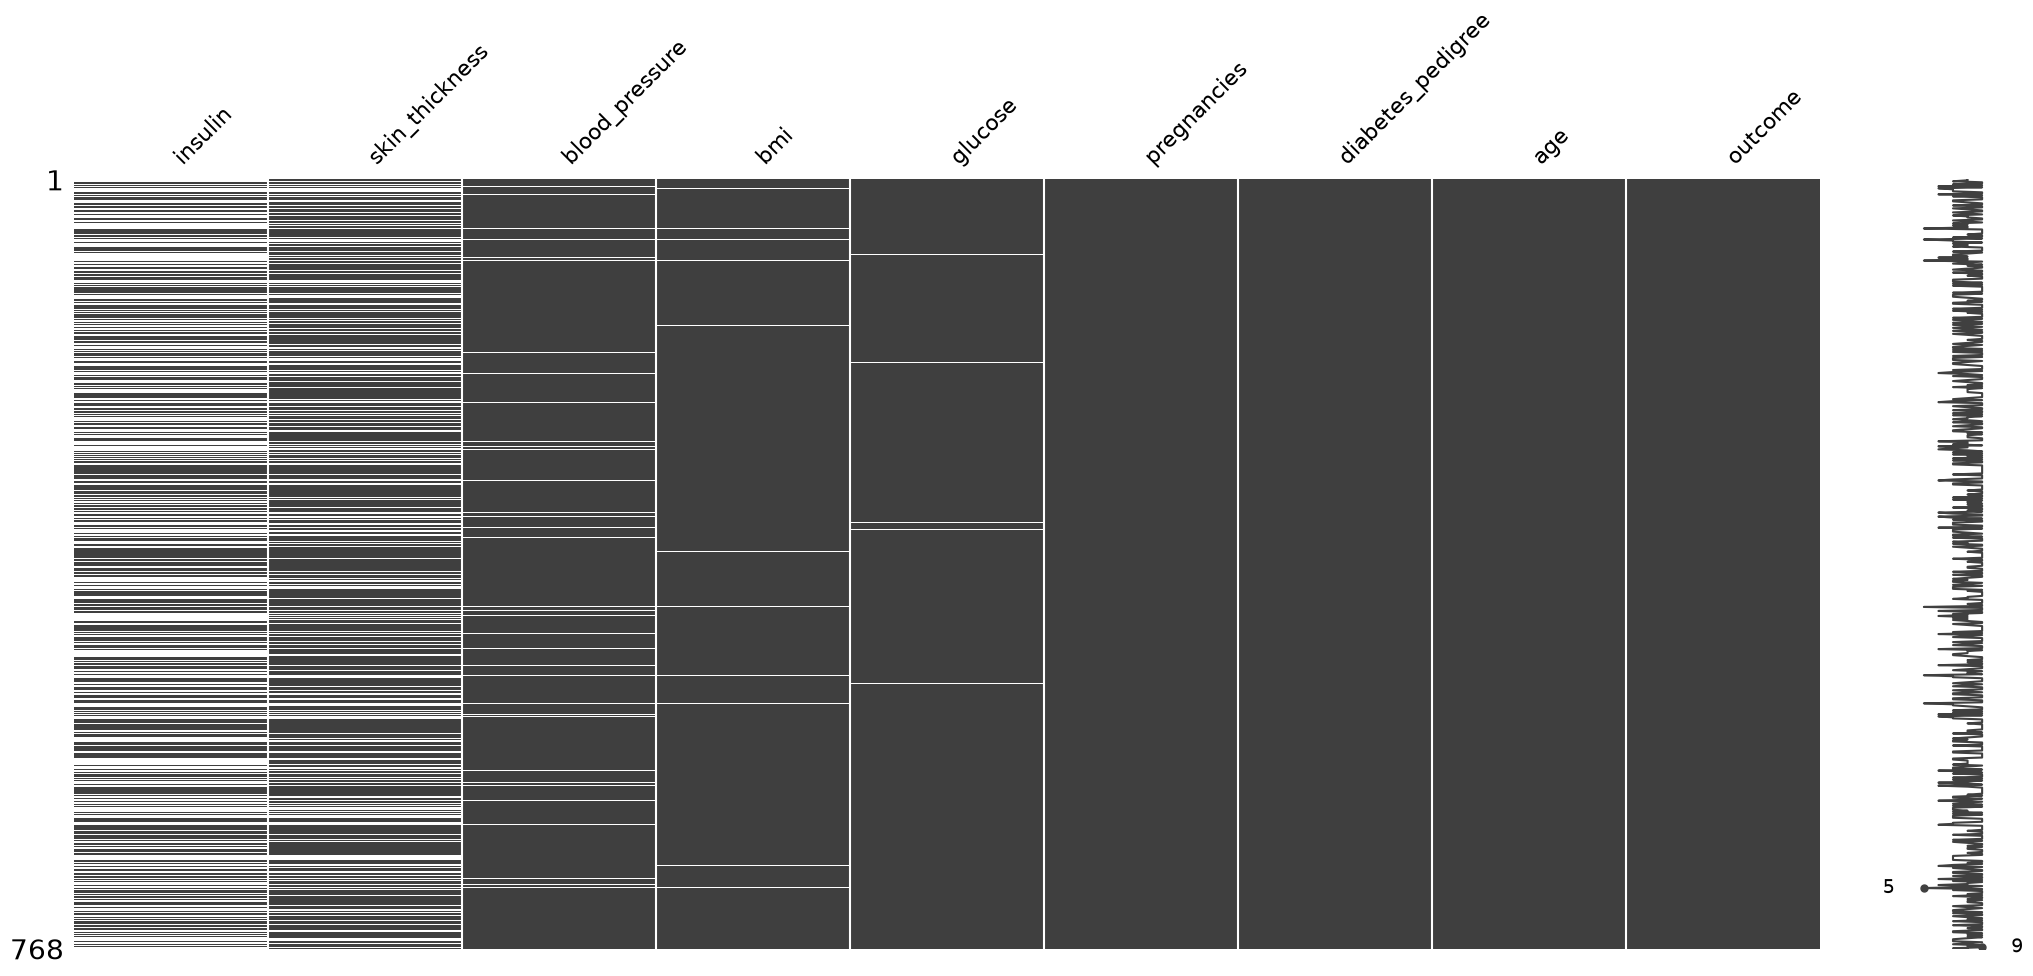

In [52]:
(
    diabetes_df
    .missing.sort_variables_by_missingness()
    .pipe(msno.matrix)
)

#### Missing At Random (MAR)

- Los faltantes se relacionan con otra variable observada.
- Ordenar el dataset por una columna ayuda a ver si los faltantes aparecen alineados con esa variable.
- Puede haber cierta estructura, aunque no tan evidente como en MNAR.

**Interpretación:**

- la ausencia depende de una condición observable.

<Axes: >

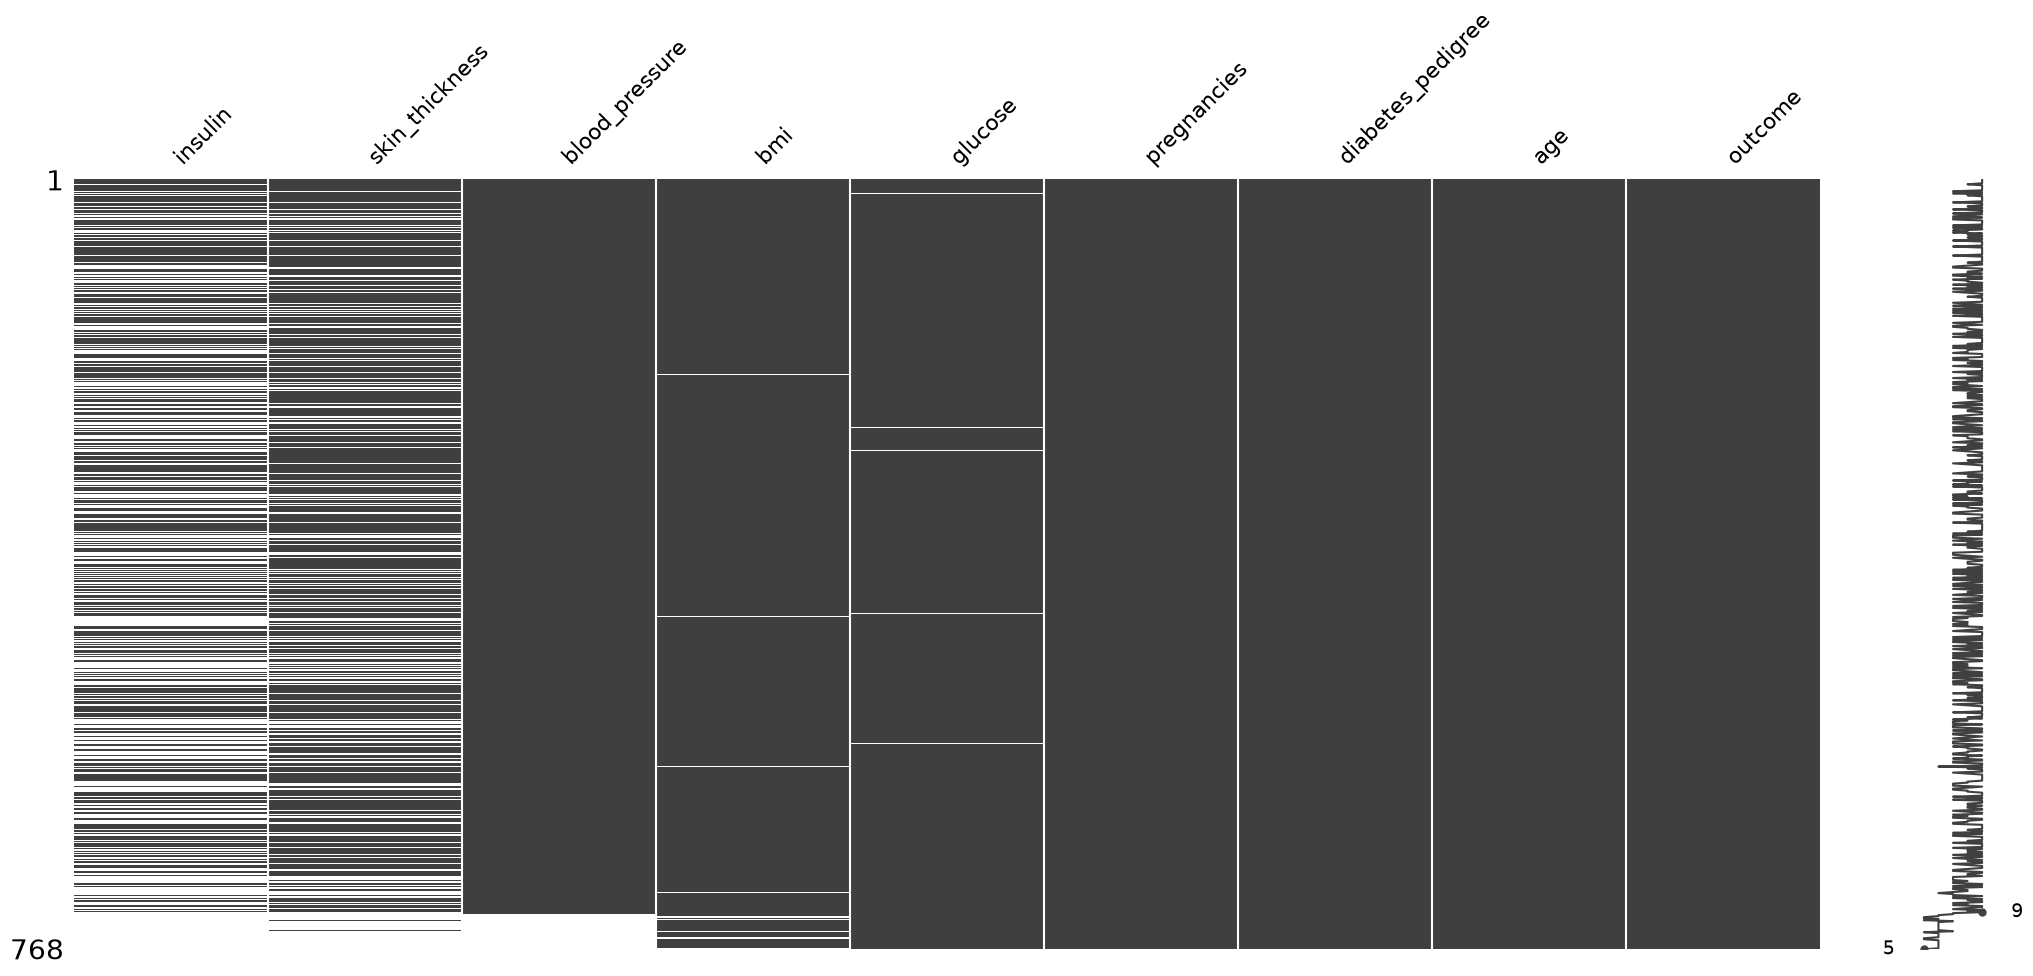

In [57]:
(
    diabetes_df
    .missing.sort_variables_by_missingness()
    .sort_values( by="blood_pressure")
    .pipe(msno.matrix)
)

#### Missing Not At Random (MNAR)

- Los faltantes tienden a agruparse de forma más marcada.
- Algunas variables muestran huecos que podrían depender del propio valor ausente o de límites de medición.
- Se observa una acumulación más “sospechosa” o sistemática.


**Interpretación:**

- El mecanismo podría estar ligado al valor que falta en sí mismo.

<Axes: >

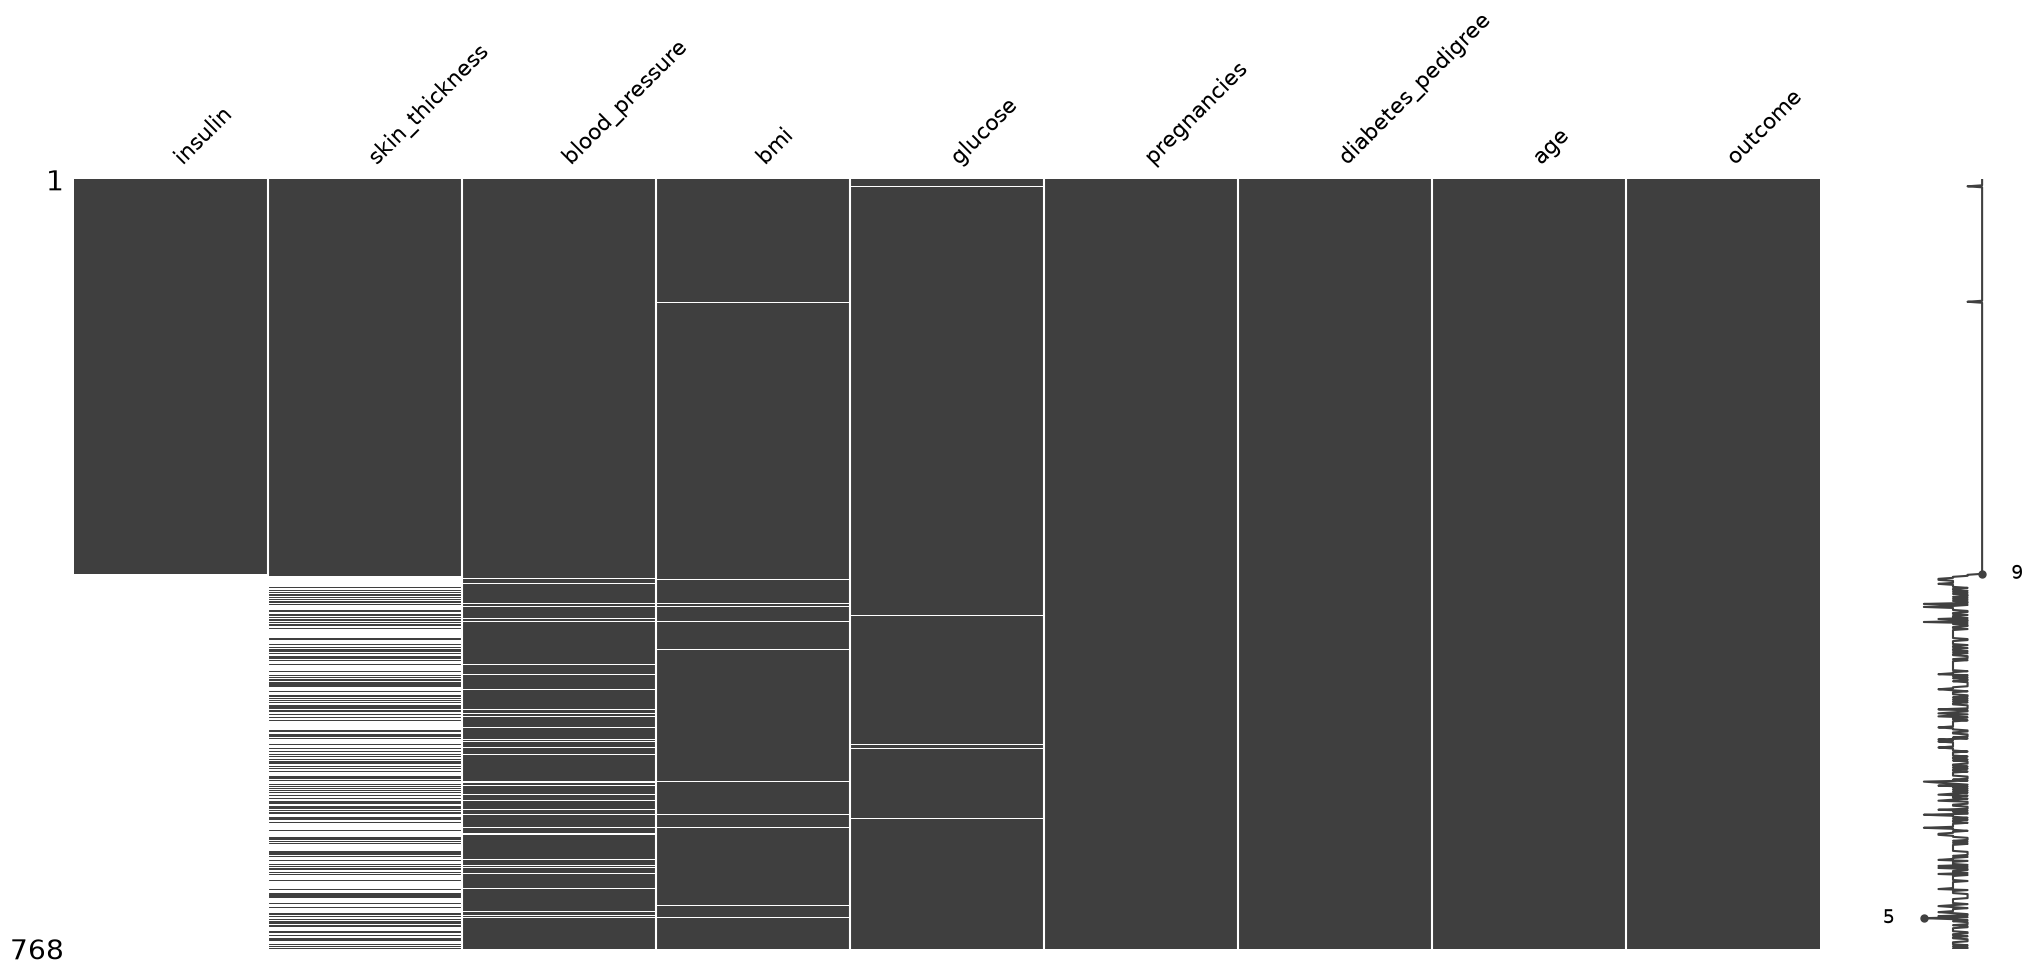

In [59]:
(
    diabetes_df
    .missing.sort_variables_by_missingness()
    .sort_values( by="insulin")
    .pipe(msno.matrix)
)